In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)

In [2]:
df_train=pd.read_parquet('training_project_1.parquet')
df_test=pd.read_parquet('testing_project_1.parquet')

In [3]:
df_train.shape

(175341, 36)

In [4]:
df_train.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,8495.365234,0,0,24.295601,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,503571.312500,2,17,49.915001,15.432865,61.426933,1387.778320,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,60929.230469,1,6,231.875565,102.737206,17179.585938,11420.925781,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,3358.622070,1,3,152.876541,90.235725,259.080170,4991.784668,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,3987.059814,2,1,47.750332,75.659599,2415.837646,115.806999,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,2,1,0,0,0,0,Normal,0


In [5]:
df_train.columns

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt',
       'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt',
       'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports',
       'attack_cat', 'label'],
      dtype='object')

In [6]:
df_train.columns.shape

(36,)

In [7]:
df_train.describe()

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,95406.179688,7.345403e+07,6.712056e+05,4.953000,6.948010,985.976929,88.216301,4.976254e+03,604.353821,116.257339,9.692504e+08,9.688770e+08,115.013625,0.041396,0.021020,0.020375,136.751769,124.173382,0.105982,2.144292e+03,5.383538,4.206255,0.014948,0.014948,0.133066,0.015752,0.680622
std,6.483313,136.887597,110.258271,1.747656e+05,1.436542e+05,165417.671875,1.883701e+08,2.423637e+06,66.005059,52.732999,7244.195801,985.741211,4.498317e+04,4056.382568,127.001024,1.355264e+09,1.354000e+09,126.886530,0.079340,0.043349,0.040521,204.677360,258.317056,0.776911,5.420797e+04,8.047104,5.783585,0.126048,0.126048,0.701208,0.124516,0.466237
min,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,28.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,32.786140,1.305334e+04,0.000000e+00,0.000000,0.000000,0.008000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,57.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3225.806641,8.796748e+05,1.447023e+03,0.000000,0.000000,0.279733,0.006000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,73.000000,44.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,125000.000000,8.888889e+07,2.784487e+04,3.000000,2.000000,55.156895,51.053001,2.513295e+03,114.990623,255.000000,1.916651e+09,1.913675e+09,255.000000,0.065481,0.023268,0.038906,100.000000,89.000000,0.000000,0.000000e+00,5.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1000000.000000,5.988000e+09,2.242273e+07,4803.000000,5484.000000,84371.492188,56716.824219,1.460480e+06,289388.281250,255.000000,4.294959e+09,4.294882e+09,255.000000,2.518893,2.100352,1.520884,1504.000000,1458.000000,172.000000,6.558056e+06,51.000000,46.000000,4.000000,4.000000,30.000000,1.000000,1.000000


In [8]:
df_train.dtypes

dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_mthd         int8
is_sm_ips_

In [9]:
df_train.state.value_counts()

state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64

In [10]:
df_train.proto.value_counts()

proto
tcp     79946
udp     63283
unas    12084
arp      2859
ospf     2595
        ...  
hmp        98
rdp        98
igmp       18
icmp       15
rtp         1
Name: count, Length: 133, dtype: int64

In [11]:
df_train.service.value_counts()

service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64

In [12]:
df_train.attack_cat.value_counts()

attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

In [13]:
df_train.isna().sum()

dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
is_sm_ips_ports      0
attack_cat           0
label                0
dtype: int64

In [14]:
df_train.drop(['attack_cat'],axis=1,inplace=True)

In [15]:
df_train

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,1.415894e+04,8495.365234,0,0,24.295601,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,1,0,0,0,0,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8.395112e+03,503571.312500,2,17,49.915001,15.432865,61.426933,1387.778320,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,1,1,0,0,0,0,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1.572272e+03,60929.230469,1,6,231.875565,102.737206,17179.585938,11420.925781,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,1,1,0,0,0,0,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2.740179e+03,3358.622070,1,3,152.876541,90.235725,259.080170,4991.784668,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,1,1,0,0,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8.561499e+03,3987.059814,2,1,47.750332,75.659599,2415.837646,115.806999,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,2,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,24,13,0,0,0,0,1
175337,0.505762,tcp,-,FIN,10,8,620,354,33.612648,8.826286e+03,4903.492188,2,1,54.400112,66.980568,3721.068848,120.177727,255,3518776216,3453092386,255,0.099440,0.036895,0.062545,62,44,0,0,1,1,0,0,0,0,1
175338,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,3,3,0,0,0,0,1
175339,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,30,14,0,0,0,0,1


In [16]:
df_train.loc[df_train.duplicated()]

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
58,0.000000,arp,-,INT,1,0,46,0,0.000000,0.000000e+00,0.0000,0,0,0.000000,0.000,0.0,0.0,0,0,0,0,0.0,0.0,0.0,46,0,0,0,1,1,0,0,0,1,0
66,50.004398,ospf,-,INT,6,0,384,0,0.099991,5.119550e+01,0.0000,0,0,10000.879883,0.000,0.0,0.0,0,0,0,0,0.0,0.0,0.0,64,0,0,0,1,2,0,0,0,0,0
169,0.000011,udp,-,INT,2,0,2120,0,90909.093750,7.709091e+08,0.0000,0,0,0.011000,0.000,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1060,0,0,0,7,2,0,0,0,0,0
214,0.001146,udp,dns,CON,2,2,146,178,2617.801025,5.095986e+05,621291.4375,0,0,0.009000,0.006,0.0,0.0,0,0,0,0,0.0,0.0,0.0,73,89,0,0,2,2,0,0,0,0,0
313,0.001098,udp,dns,CON,2,2,132,164,2732.240479,4.808743e+05,597449.9375,0,0,0.010000,0.008,0.0,0.0,0,0,0,0,0.0,0.0,0.0,66,82,0,0,3,2,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175335,0.000006,udp,dns,INT,2,0,114,0,166666.656250,7.600000e+07,0.0000,0,0,0.006000,0.000,0.0,0.0,0,0,0,0,0.0,0.0,0.0,57,0,0,0,33,17,0,0,0,0,1
175336,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,0.0000,0,0,0.009000,0.000,0.0,0.0,0,0,0,0,0.0,0.0,0.0,57,0,0,0,24,13,0,0,0,0,1
175338,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,0.0000,0,0,0.009000,0.000,0.0,0.0,0,0,0,0,0.0,0.0,0.0,57,0,0,0,3,3,0,0,0,0,1
175339,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,0.0000,0,0,0.009000,0.000,0.0,0.0,0,0,0,0,0.0,0.0,0.0,57,0,0,0,30,14,0,0,0,0,1


In [17]:
df_train

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,1.415894e+04,8495.365234,0,0,24.295601,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,1,0,0,0,0,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8.395112e+03,503571.312500,2,17,49.915001,15.432865,61.426933,1387.778320,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,1,1,0,0,0,0,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1.572272e+03,60929.230469,1,6,231.875565,102.737206,17179.585938,11420.925781,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,1,1,0,0,0,0,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2.740179e+03,3358.622070,1,3,152.876541,90.235725,259.080170,4991.784668,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,1,1,0,0,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8.561499e+03,3987.059814,2,1,47.750332,75.659599,2415.837646,115.806999,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,2,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,24,13,0,0,0,0,1
175337,0.505762,tcp,-,FIN,10,8,620,354,33.612648,8.826286e+03,4903.492188,2,1,54.400112,66.980568,3721.068848,120.177727,255,3518776216,3453092386,255,0.099440,0.036895,0.062545,62,44,0,0,1,1,0,0,0,0,1
175338,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,3,3,0,0,0,0,1
175339,0.000009,udp,dns,INT,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,30,14,0,0,0,0,1


In [18]:
for col in ['trans_depth',
       'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd','is_sm_ips_ports']:
    print(f"\nValue counts for {col}:")
    print(df_train[col].value_counts())


Value counts for trans_depth:
trans_depth
0      157501
1       17747
2          80
4           3
5           2
39          2
3           2
80          1
155         1
163         1
172         1
Name: count, dtype: int64

Value counts for response_body_len:
response_body_len
0         164047
3924        2768
83           580
524288       386
109          333
           ...  
6077           1
1247           1
888            1
1695           1
45665          1
Name: count, Length: 2386, dtype: int64

Value counts for ct_src_dport_ltm:
ct_src_dport_ltm
1     92793
2     24949
3      9322
16     8458
17     6325
4      4006
33     2612
18     2566
6      2011
5      1825
8      1738
14     1719
10     1564
12     1541
13     1525
34     1329
15     1313
11     1284
9      1267
7      1159
32      659
25      424
28      402
27      395
30      375
24      370
20      361
29      351
23      344
31      323
21      306
19      292
26      271
22      257
36      175
41      123
42       8

In [19]:
from sklearn.preprocessing import LabelEncoder

In [20]:
categorical_cols = ['proto', 'service', 'state']
for col in categorical_cols:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col])

In [21]:
df_train

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
0,0.121478,113,0,2,6,4,258,172,74.087486,1.415894e+04,8495.365234,0,0,24.295601,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,1,0,0,0,0,0
1,0.649902,113,0,2,14,38,734,42014,78.473373,8.395112e+03,503571.312500,2,17,49.915001,15.432865,61.426933,1387.778320,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,1,1,0,0,0,0,0
2,1.623129,113,0,2,8,16,364,13186,14.170161,1.572272e+03,60929.230469,1,6,231.875565,102.737206,17179.585938,11420.925781,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,1,1,0,0,0,0,0
3,1.681642,113,3,2,12,12,628,770,13.677108,2.740179e+03,3358.622070,1,3,152.876541,90.235725,259.080170,4991.784668,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,1,1,0,0,0
4,0.449454,113,0,2,10,6,534,268,33.373825,8.561499e+03,3987.059814,2,1,47.750332,75.659599,2415.837646,115.806999,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,2,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,0.000009,119,2,3,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,24,13,0,0,0,0,1
175337,0.505762,113,0,2,10,8,620,354,33.612648,8.826286e+03,4903.492188,2,1,54.400112,66.980568,3721.068848,120.177727,255,3518776216,3453092386,255,0.099440,0.036895,0.062545,62,44,0,0,1,1,0,0,0,0,1
175338,0.000009,119,2,3,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,3,3,0,0,0,0,1
175339,0.000009,119,2,3,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,30,14,0,0,0,0,1


In [22]:
(df_train['ct_ftp_cmd'] == df_train['is_ftp_login']).all()

np.True_

In [23]:
df_train[['ct_ftp_cmd', 'is_ftp_login']].corr()

,ct_ftp_cmd,is_ftp_login
ct_ftp_cmd,1.0,1.0
is_ftp_login,1.0,1.0


In [24]:
df_train.drop(['is_ftp_login'],axis=1,inplace=True)

In [25]:
df_train

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
0,0.121478,113,0,2,6,4,258,172,74.087486,1.415894e+04,8495.365234,0,0,24.295601,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,1,0,0,0,0
1,0.649902,113,0,2,14,38,734,42014,78.473373,8.395112e+03,503571.312500,2,17,49.915001,15.432865,61.426933,1387.778320,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,1,1,0,0,0,0
2,1.623129,113,0,2,8,16,364,13186,14.170161,1.572272e+03,60929.230469,1,6,231.875565,102.737206,17179.585938,11420.925781,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,1,1,0,0,0,0
3,1.681642,113,3,2,12,12,628,770,13.677108,2.740179e+03,3358.622070,1,3,152.876541,90.235725,259.080170,4991.784668,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,1,0,0,0
4,0.449454,113,0,2,10,6,534,268,33.373825,8.561499e+03,3987.059814,2,1,47.750332,75.659599,2415.837646,115.806999,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,2,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,0.000009,119,2,3,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,24,13,0,0,0,1
175337,0.505762,113,0,2,10,8,620,354,33.612648,8.826286e+03,4903.492188,2,1,54.400112,66.980568,3721.068848,120.177727,255,3518776216,3453092386,255,0.099440,0.036895,0.062545,62,44,0,0,1,1,0,0,0,1
175338,0.000009,119,2,3,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,3,3,0,0,0,1
175339,0.000009,119,2,3,2,0,114,0,111111.109375,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,30,14,0,0,0,1


In [26]:
import seaborn as sns

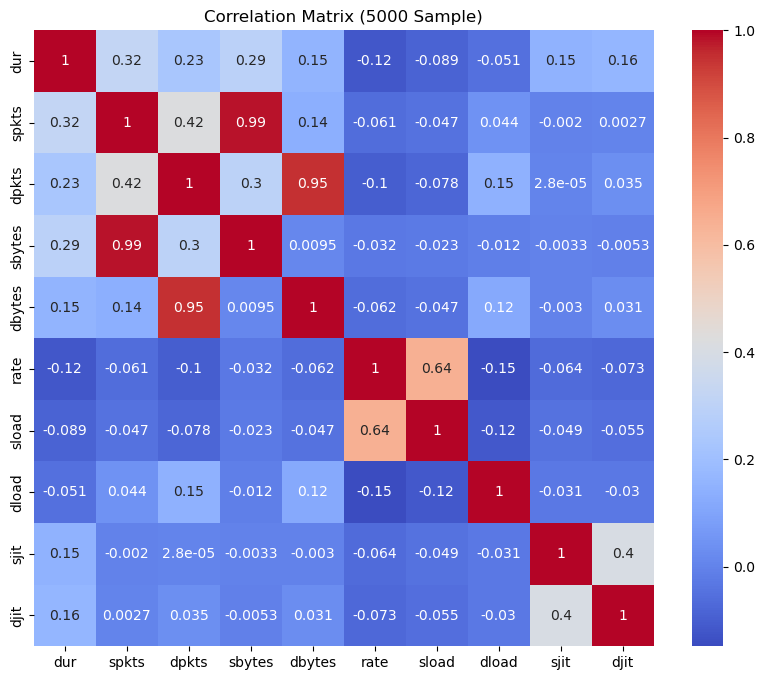

In [27]:
sample_df = df_train.sample(5000, random_state=42)
cols = [
    'dur',
    'spkts',
    'dpkts',
    'sbytes',
    'dbytes',
    'rate',
    'sload',
    'dload',
    'sjit',
    'djit'
]

plt.figure(figsize=(10, 8))
sns.heatmap(sample_df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix (5000 Sample)")
plt.show()

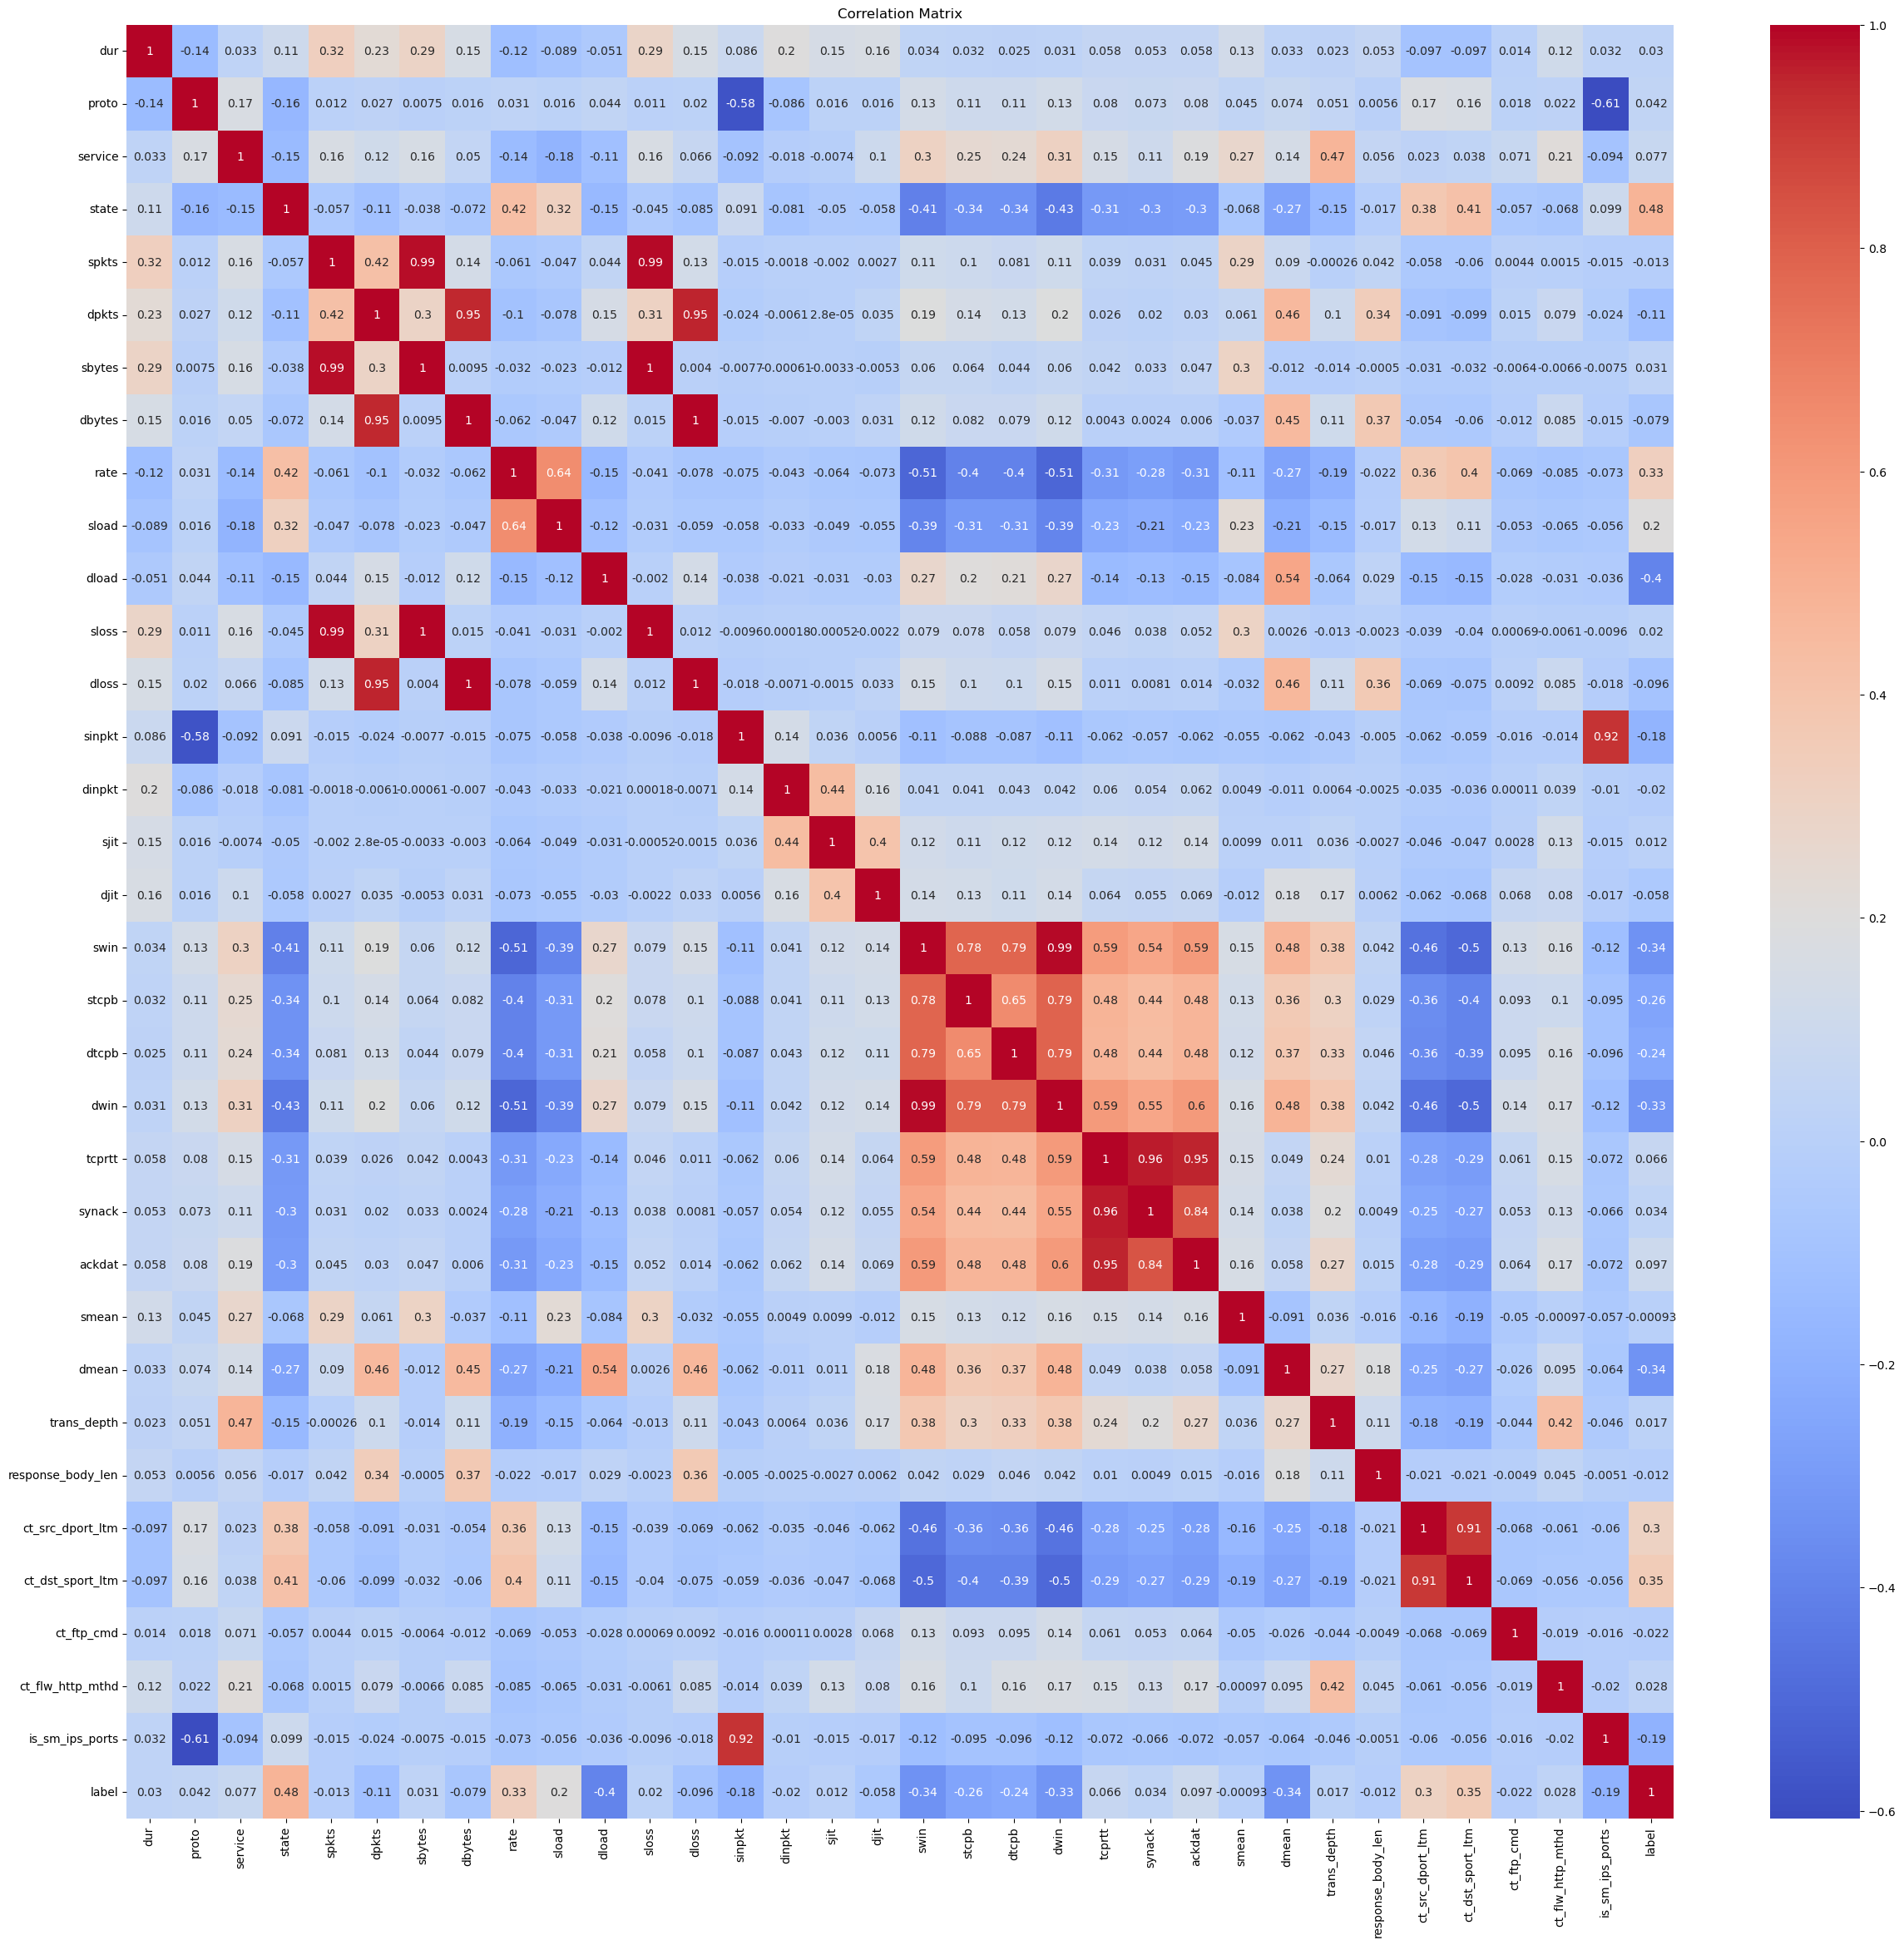

In [28]:
plt.figure(figsize=(30, 28))
sns.heatmap(sample_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [29]:
def correlation(dataset, threshold):
    correlated_features = set()
    corr_matrix = df_train.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                col_name = corr_matrix.columns[i]
                correlated_features.add(col_name)
    return correlated_features

In [30]:
correlation(df_train,0.95)

{'dbytes', 'dloss', 'dwin', 'sbytes', 'sloss'}

In [31]:
df_train.drop(['dbytes', 'dloss', 'dwin', 'sbytes', 'sloss'],axis=1,inplace=True)

In [32]:
df_train

,dur,proto,service,state,spkts,dpkts,rate,sload,dload,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,label
0,0.121478,113,0,2,6,4,74.087486,1.415894e+04,8495.365234,24.295601,8.375000,30.177547,11.830604,255,621772692,2202533631,0.000000,0.000000,0.000000,43,43,0,0,1,1,0,0,0,0
1,0.649902,113,0,2,14,38,78.473373,8.395112e+03,503571.312500,49.915001,15.432865,61.426933,1387.778320,255,1417884146,3077387971,0.000000,0.000000,0.000000,52,1106,0,0,1,1,0,0,0,0
2,1.623129,113,0,2,8,16,14.170161,1.572272e+03,60929.230469,231.875565,102.737206,17179.585938,11420.925781,255,2116150707,2963114973,0.111897,0.061458,0.050439,46,824,0,0,1,1,0,0,0,0
3,1.681642,113,3,2,12,12,13.677108,2.740179e+03,3358.622070,152.876541,90.235725,259.080170,4991.784668,255,1107119177,1047442890,0.000000,0.000000,0.000000,52,64,0,0,1,1,1,0,0,0
4,0.449454,113,0,2,10,6,33.373825,8.561499e+03,3987.059814,47.750332,75.659599,2415.837646,115.806999,255,2436137549,1977154190,0.128381,0.071147,0.057234,53,45,0,0,2,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,0.000009,119,2,3,2,0,111111.109375,5.066666e+07,0.000000,0.009000,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,24,13,0,0,0,1
175337,0.505762,113,0,2,10,8,33.612648,8.826286e+03,4903.492188,54.400112,66.980568,3721.068848,120.177727,255,3518776216,3453092386,0.099440,0.036895,0.062545,62,44,0,0,1,1,0,0,0,1
175338,0.000009,119,2,3,2,0,111111.109375,5.066666e+07,0.000000,0.009000,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,3,3,0,0,0,1
175339,0.000009,119,2,3,2,0,111111.109375,5.066666e+07,0.000000,0.009000,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,30,14,0,0,0,1


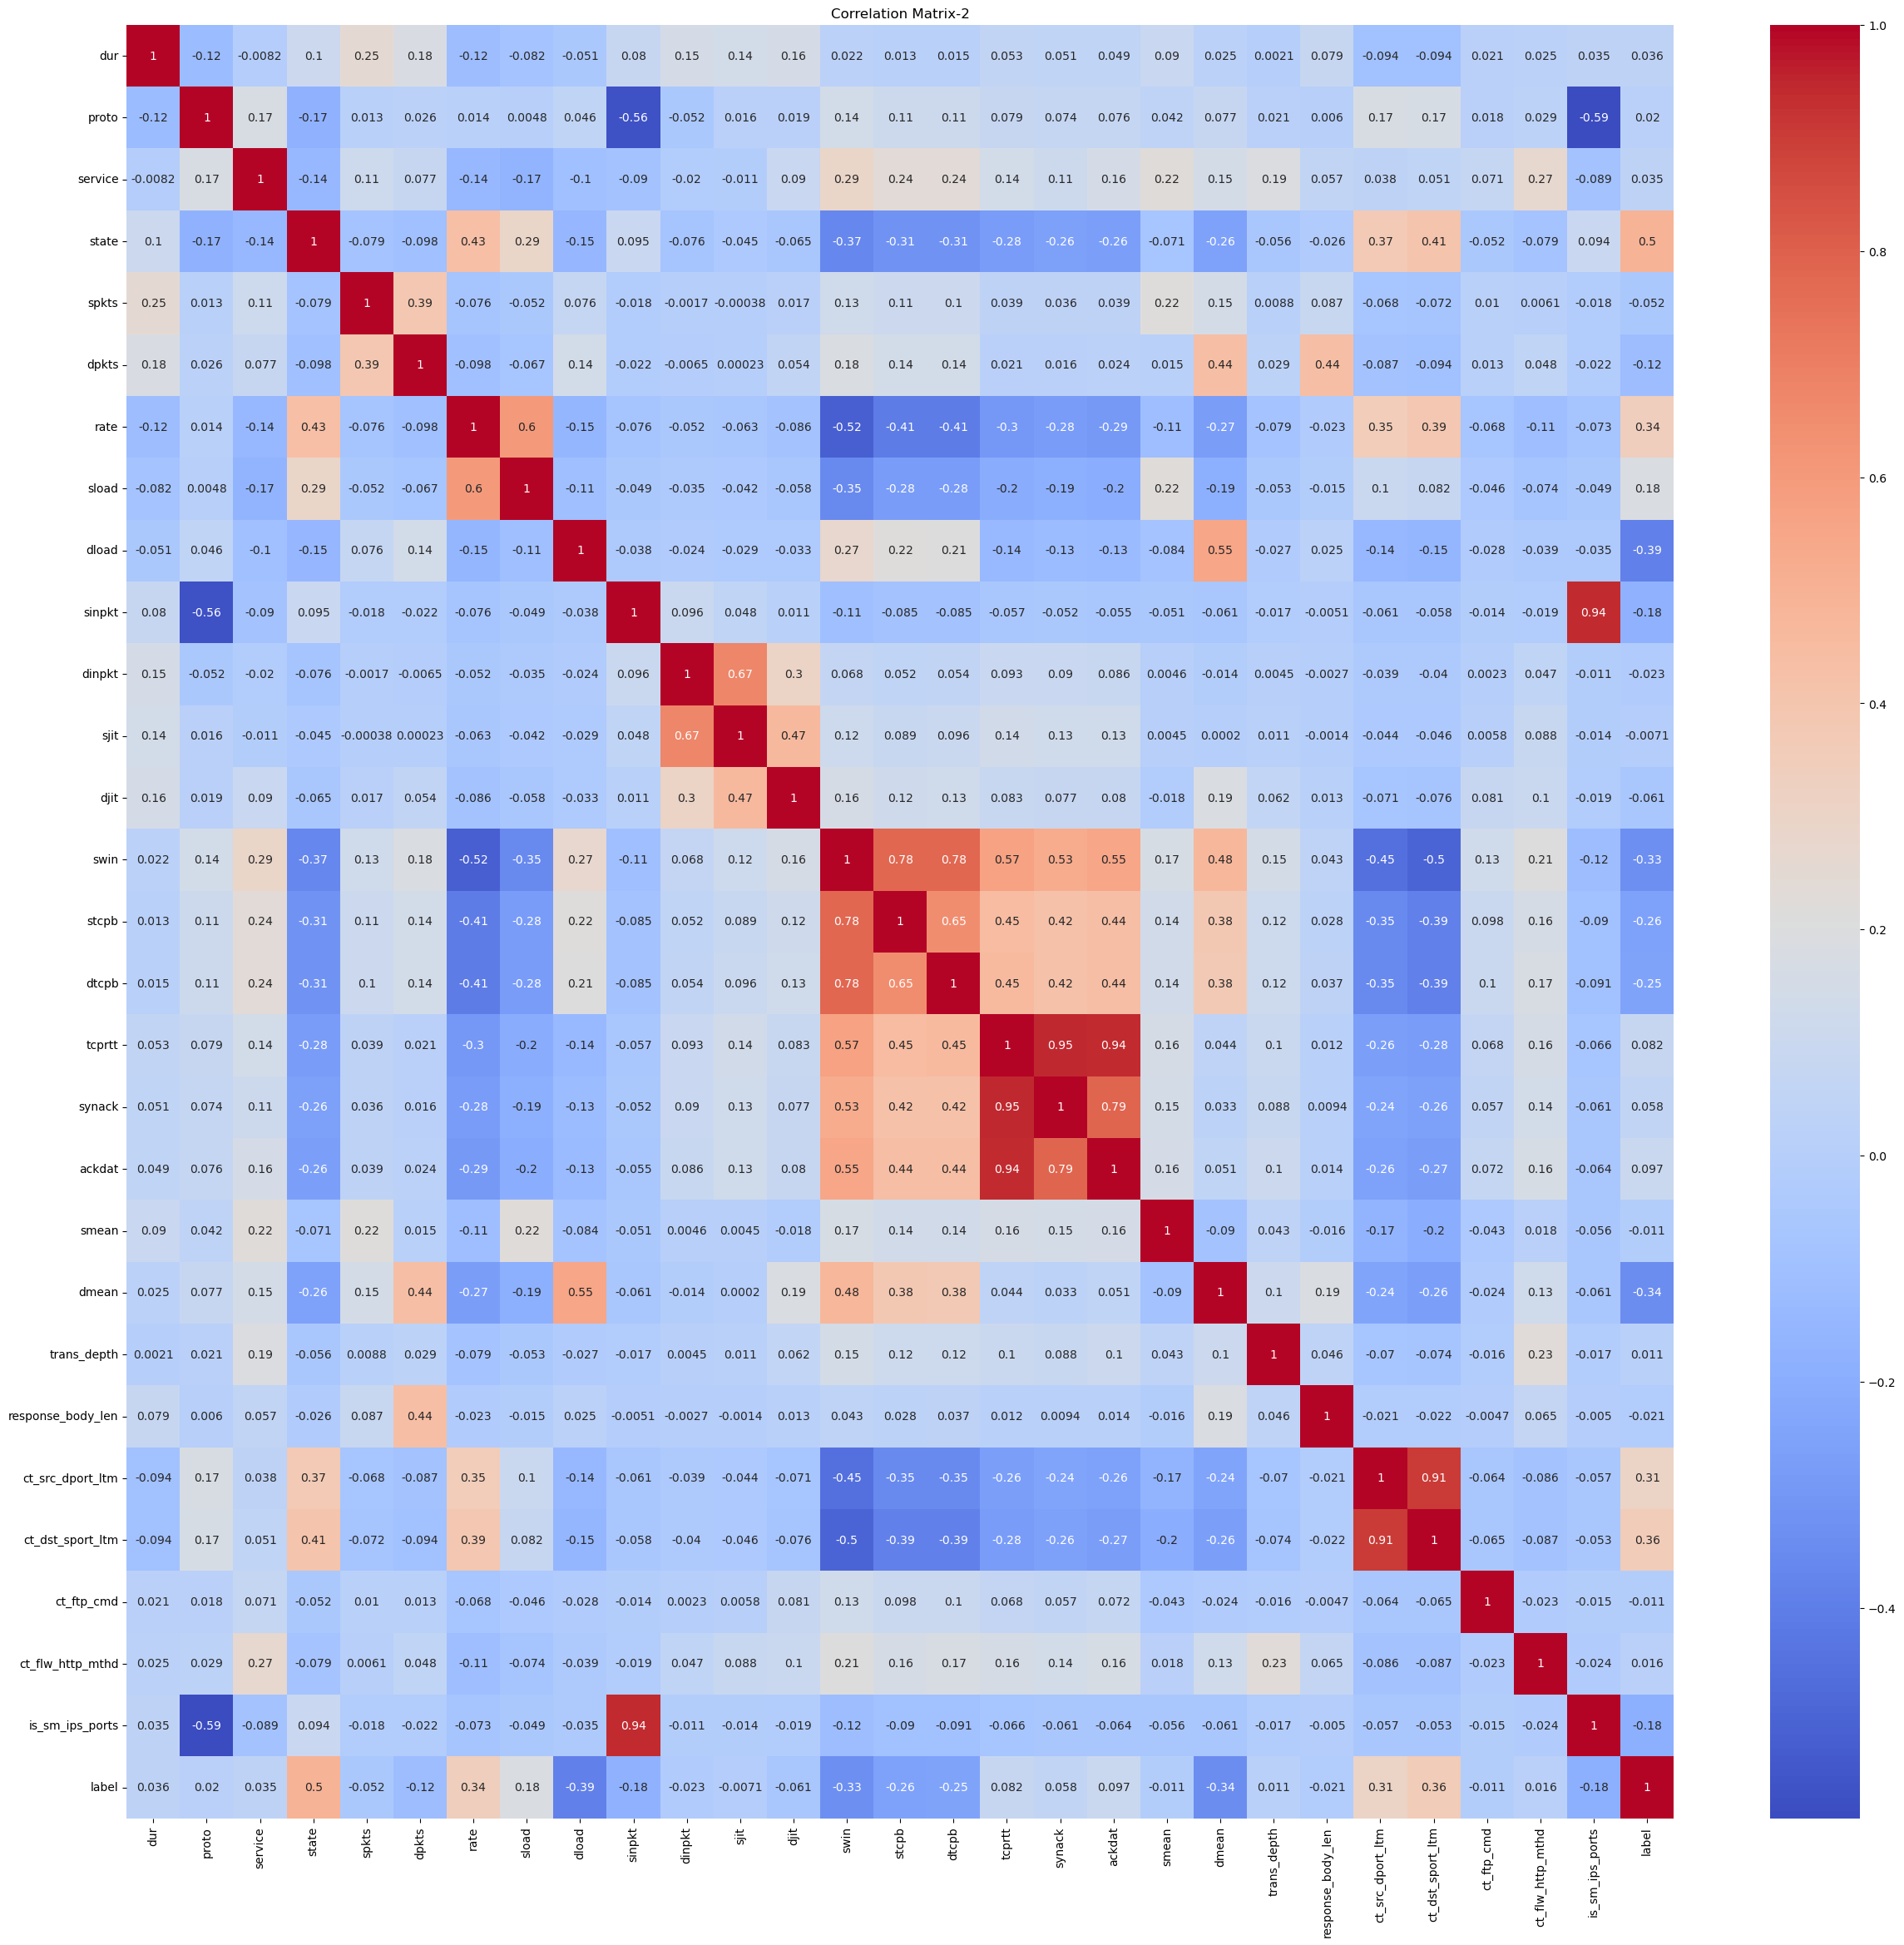

In [33]:
plt.figure(figsize=(30, 28))
sns.heatmap(df_train.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix-2")
plt.show()

In [34]:
for col in df_train.columns:
    print(col, df_train[col].value_counts(normalize=True).head(1))

dur dur
0.000009    0.13135
Name: proportion, dtype: float64
proto proto
113    0.455946
Name: proportion, dtype: float64
service service
0    0.537056
Name: proportion, dtype: float64
state state
3    0.469229
Name: proportion, dtype: float64
spkts spkts
2    0.48591
Name: proportion, dtype: float64
dpkts dpkts
0    0.480675
Name: proportion, dtype: float64
rate rate
111111.109375    0.131241
Name: proportion, dtype: float64
sload sload
50666664.0    0.068421
Name: proportion, dtype: float64
dload dload
0.0    0.48072
Name: proportion, dtype: float64
sinpkt sinpkt
0.009    0.149269
Name: proportion, dtype: float64
dinpkt dinpkt
0.0    0.480738
Name: proportion, dtype: float64
sjit sjit
0.0    0.504697
Name: proportion, dtype: float64
djit djit
0.0    0.534633
Name: proportion, dtype: float64
swin swin
0    0.544054
Name: proportion, dtype: float64
stcpb stcpb
0    0.548908
Name: proportion, dtype: float64
dtcpb dtcpb
0    0.548942
Name: proportion, dtype: float64
tcprtt tcprtt
0.0    

In [35]:
pd.crosstab(df_train['is_sm_ips_ports'], df_train['label'])

label,0,1
is_sm_ips_ports,,
0,53238,119341
1,2762,0


In [36]:
from sklearn.feature_selection import mutual_info_classif

In [37]:
x=df_train.drop('label',axis=1)
y=df_train['label']
mi=mutual_info_classif(x,y)

In [38]:
mi_df = pd.DataFrame({
    'Feature': x.columns,
    'MI Score': mi
})

In [39]:
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
mi_df

,Feature,MI Score
6,rate,0.353410
7,sload,0.347205
0,dur,0.339351
19,smean,0.334768
20,dmean,0.313840
10,dinpkt,0.298562
8,dload,0.280754
5,dpkts,0.272994
9,sinpkt,0.247237
16,tcprtt,0.237732


In [40]:
cols=['ct_flw_http_mthd','trans_depth','ct_ftp_cmd']
for col in cols:
    print(pd.crosstab(df_train[col],df_train['label']))

label                 0       1
ct_flw_http_mthd               
0                 50820  106681
1                  4810   11886
2                    16      58
3                     0       3
4                   300     546
6                     6      30
9                    36      54
12                   12      12
16                    0      16
25                    0      25
30                    0      30
label            0       1
trans_depth               
0            50820  106681
1             5111   12636
2               69      11
3                0       2
4                0       3
5                0       2
39               0       2
80               0       1
155              0       1
163              0       1
172              0       1
label           0       1
ct_ftp_cmd               
0           55051  117723
1             947    1598
2               2       4
4               0      16


In [41]:
cols=['ct_flw_http_mthd','trans_depth','ct_ftp_cmd']
for col in cols:
    print(pd.crosstab(df_train[col],df_train['label'],normalize='index'))

label                    0         1
ct_flw_http_mthd                    
0                 0.322665  0.677335
1                 0.288093  0.711907
2                 0.216216  0.783784
3                 0.000000  1.000000
4                 0.354610  0.645390
6                 0.166667  0.833333
9                 0.400000  0.600000
12                0.500000  0.500000
16                0.000000  1.000000
25                0.000000  1.000000
30                0.000000  1.000000
label               0         1
trans_depth                    
0            0.322665  0.677335
1            0.287992  0.712008
2            0.862500  0.137500
3            0.000000  1.000000
4            0.000000  1.000000
5            0.000000  1.000000
39           0.000000  1.000000
80           0.000000  1.000000
155          0.000000  1.000000
163          0.000000  1.000000
172          0.000000  1.000000
label              0         1
ct_ftp_cmd                    
0           0.318630  0.681370
1         

In [42]:
df_train.drop(['ct_ftp_cmd'],axis=1,inplace=True)

In [43]:
df_train

,dur,proto,service,state,spkts,dpkts,rate,sload,dload,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,ct_flw_http_mthd,is_sm_ips_ports,label
0,0.121478,113,0,2,6,4,74.087486,1.415894e+04,8495.365234,24.295601,8.375000,30.177547,11.830604,255,621772692,2202533631,0.000000,0.000000,0.000000,43,43,0,0,1,1,0,0,0
1,0.649902,113,0,2,14,38,78.473373,8.395112e+03,503571.312500,49.915001,15.432865,61.426933,1387.778320,255,1417884146,3077387971,0.000000,0.000000,0.000000,52,1106,0,0,1,1,0,0,0
2,1.623129,113,0,2,8,16,14.170161,1.572272e+03,60929.230469,231.875565,102.737206,17179.585938,11420.925781,255,2116150707,2963114973,0.111897,0.061458,0.050439,46,824,0,0,1,1,0,0,0
3,1.681642,113,3,2,12,12,13.677108,2.740179e+03,3358.622070,152.876541,90.235725,259.080170,4991.784668,255,1107119177,1047442890,0.000000,0.000000,0.000000,52,64,0,0,1,1,0,0,0
4,0.449454,113,0,2,10,6,33.373825,8.561499e+03,3987.059814,47.750332,75.659599,2415.837646,115.806999,255,2436137549,1977154190,0.128381,0.071147,0.057234,53,45,0,0,2,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175336,0.000009,119,2,3,2,0,111111.109375,5.066666e+07,0.000000,0.009000,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,24,13,0,0,1
175337,0.505762,113,0,2,10,8,33.612648,8.826286e+03,4903.492188,54.400112,66.980568,3721.068848,120.177727,255,3518776216,3453092386,0.099440,0.036895,0.062545,62,44,0,0,1,1,0,0,1
175338,0.000009,119,2,3,2,0,111111.109375,5.066666e+07,0.000000,0.009000,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,3,3,0,0,1
175339,0.000009,119,2,3,2,0,111111.109375,5.066666e+07,0.000000,0.009000,0.000000,0.000000,0.000000,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,30,14,0,0,1


In [44]:
df_train.describe()

,dur,proto,service,state,spkts,dpkts,rate,sload,dload,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,ct_flw_http_mthd,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,1.753410e+05,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,1.359389,109.606675,1.618920,2.355176,20.298664,18.969591,95406.179688,7.345403e+07,6.712056e+05,985.976929,88.216301,4.976254e+03,604.353821,116.257339,9.692504e+08,9.688770e+08,0.041396,0.021020,0.020375,136.751769,124.173382,0.105982,2.144292e+03,5.383538,4.206255,0.133066,0.015752,0.680622
std,6.483313,22.352601,2.305151,0.867942,136.887597,110.258271,165417.671875,1.883701e+08,2.423637e+06,7244.195801,985.741211,4.498317e+04,4056.382568,127.001024,1.355264e+09,1.354000e+09,0.079340,0.043349,0.040521,204.677360,258.317056,0.776911,5.420797e+04,8.047104,5.783585,0.701208,0.124516,0.466237
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,28.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000008,113.000000,0.000000,2.000000,2.000000,0.000000,32.786140,1.305334e+04,0.000000e+00,0.008000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,57.000000,0.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,0.000000
50%,0.001582,113.000000,0.000000,2.000000,2.000000,2.000000,3225.806641,8.796748e+05,1.447023e+03,0.279733,0.006000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,73.000000,44.000000,0.000000,0.000000e+00,1.000000,1.000000,0.000000,0.000000,1.000000
75%,0.668069,119.000000,2.000000,3.000000,12.000000,10.000000,125000.000000,8.888889e+07,2.784487e+04,55.156895,51.053001,2.513295e+03,114.990623,255.000000,1.916651e+09,1.913675e+09,0.065481,0.023268,0.038906,100.000000,89.000000,0.000000,0.000000e+00,5.000000,3.000000,0.000000,0.000000,1.000000
max,59.999989,132.000000,12.000000,8.000000,9616.000000,10974.000000,1000000.000000,5.988000e+09,2.242273e+07,84371.492188,56716.824219,1.460480e+06,289388.281250,255.000000,4.294959e+09,4.294882e+09,2.518893,2.100352,1.520884,1504.000000,1458.000000,172.000000,6.558056e+06,51.000000,46.000000,30.000000,1.000000,1.000000


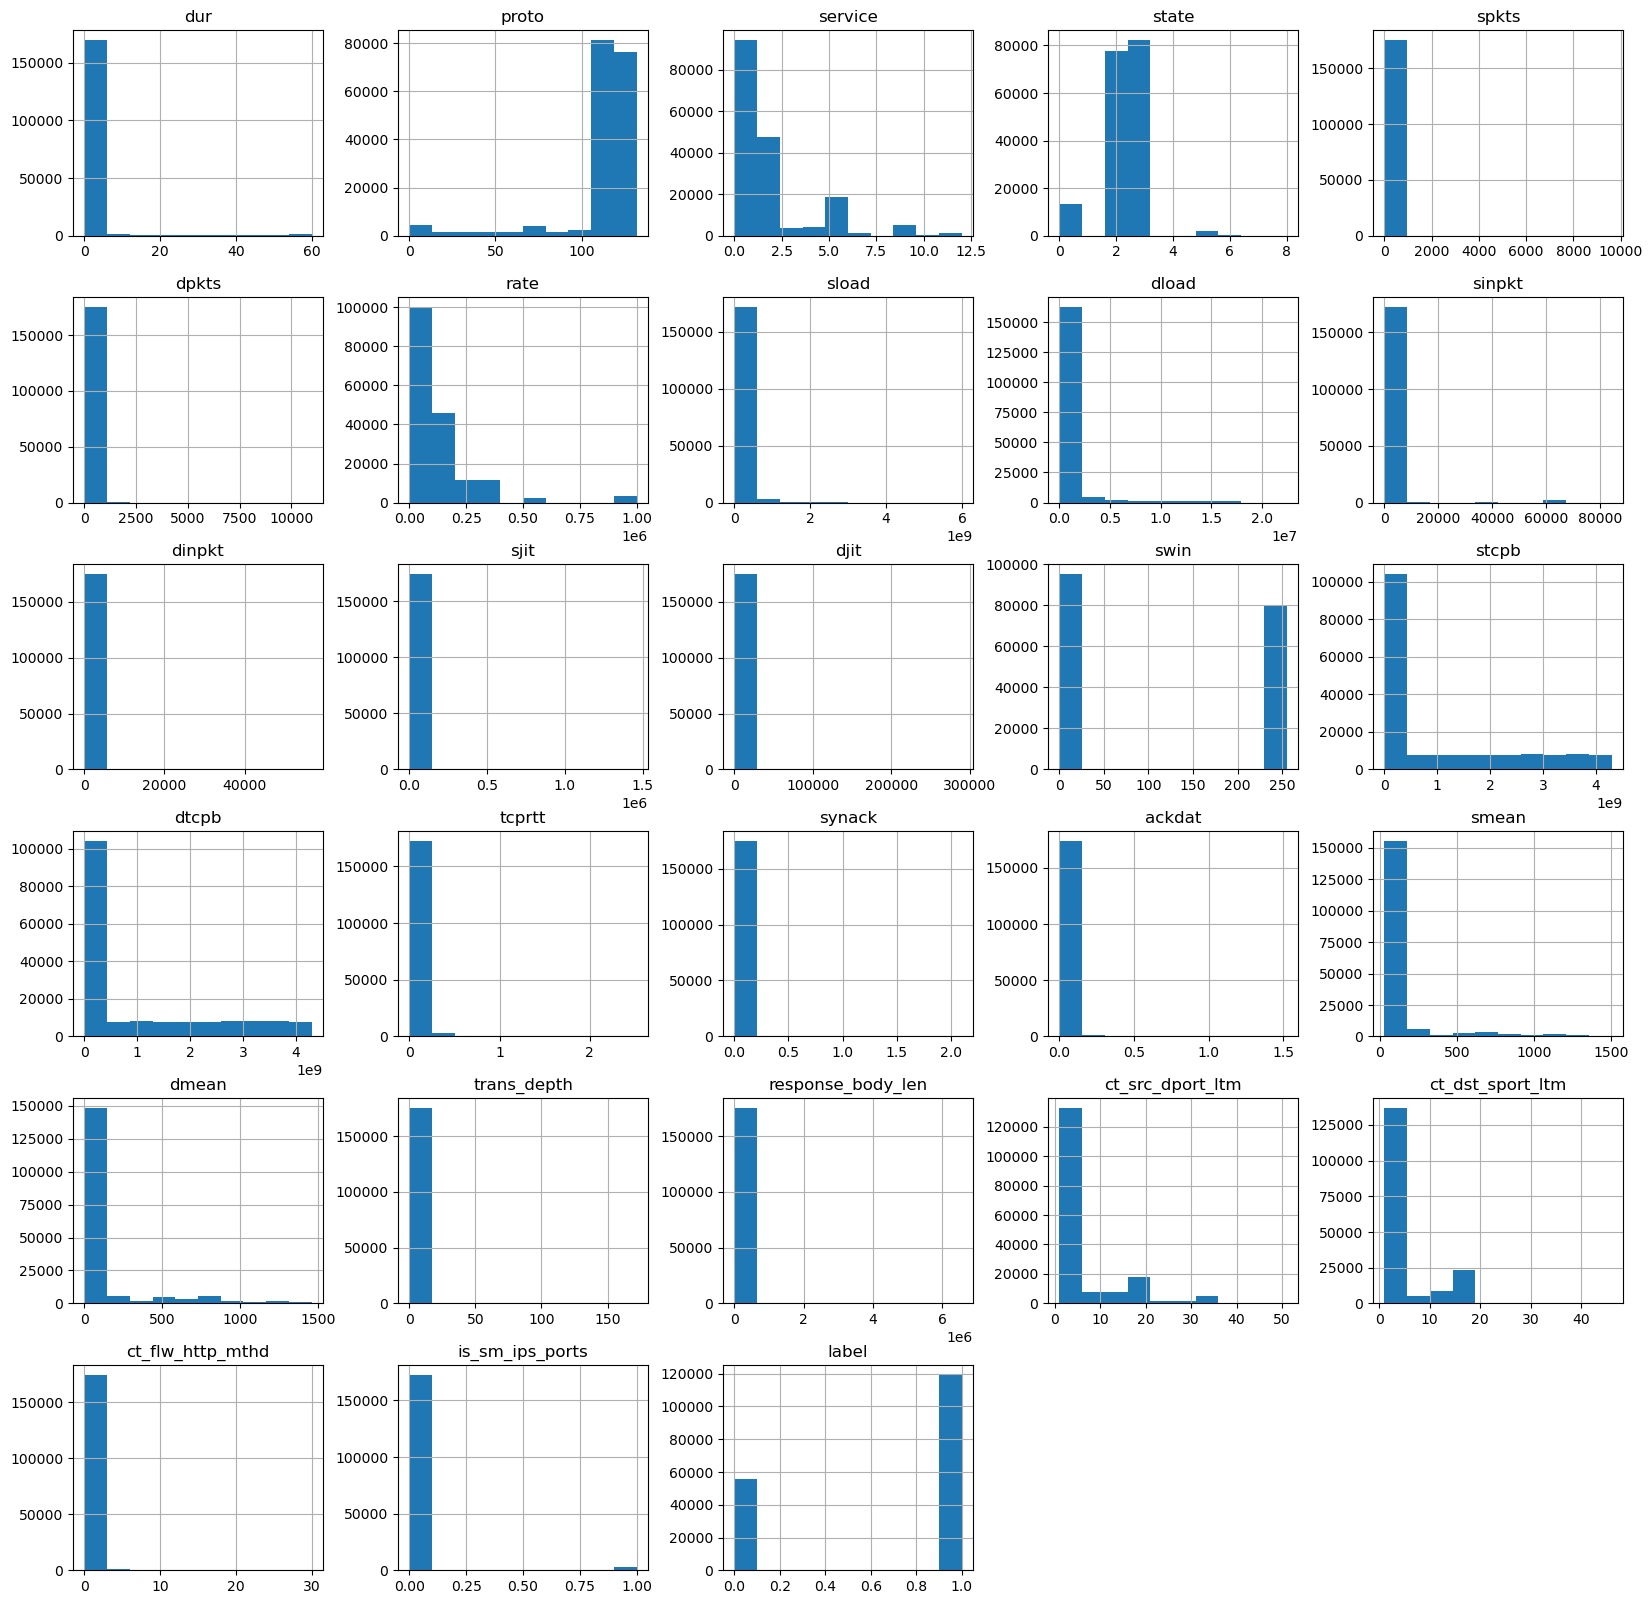

In [45]:
df_train.hist(figsize=(20,20))
plt.show()

In [46]:
df_train.skew().sort_values(ascending=False)

trans_depth          167.335829
response_body_len     76.340075
spkts                 40.217703
dpkts                 36.764114
dinpkt                29.679512
djit                  29.543831
ct_flw_http_mthd      23.451424
sjit                  17.652157
sload                  8.703399
sinpkt                 7.917535
is_sm_ips_ports        7.778199
dur                    7.496060
synack                 5.786286
ackdat                 5.615605
dload                  4.691217
tcprtt                 4.038359
smean                  3.726623
rate                   3.319494
dmean                  2.826146
ct_src_dport_ltm       2.171187
service                1.762673
ct_dst_sport_ltm       1.696466
stcpb                  1.081121
dtcpb                  1.081017
swin                   0.177048
label                 -0.774818
state                 -0.978119
proto                 -3.577988
dtype: float64

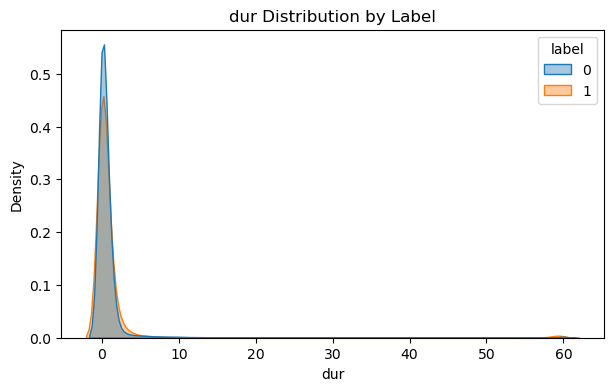

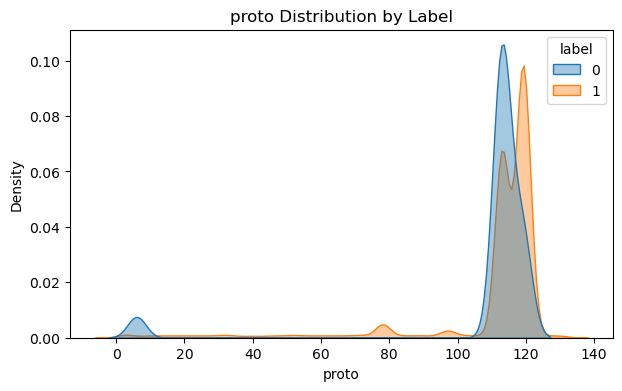

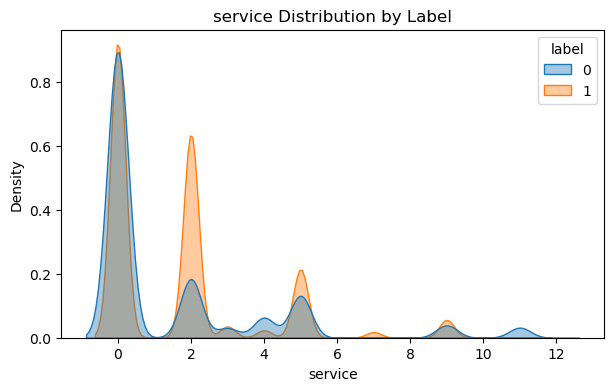

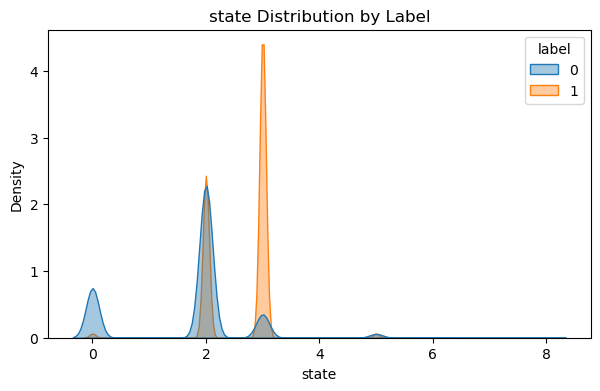

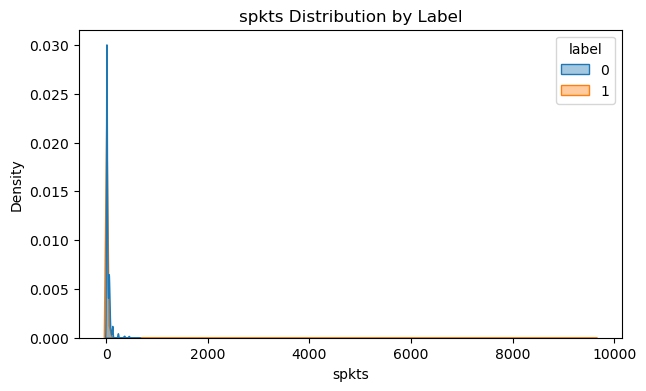

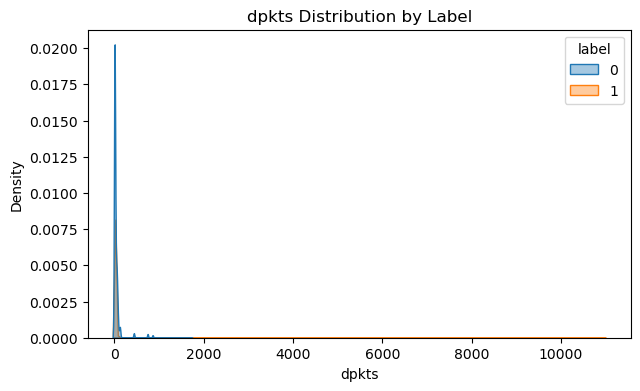

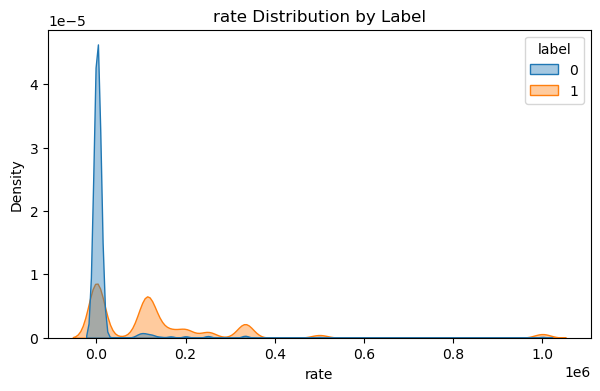

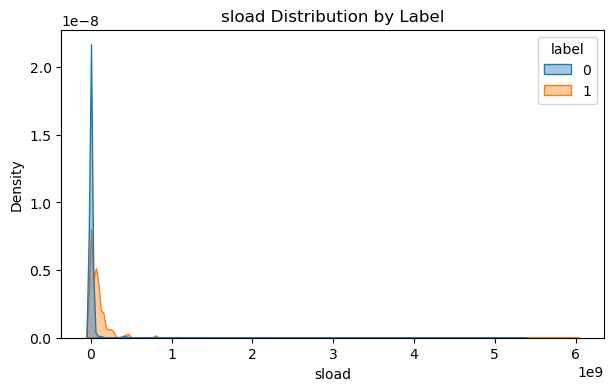

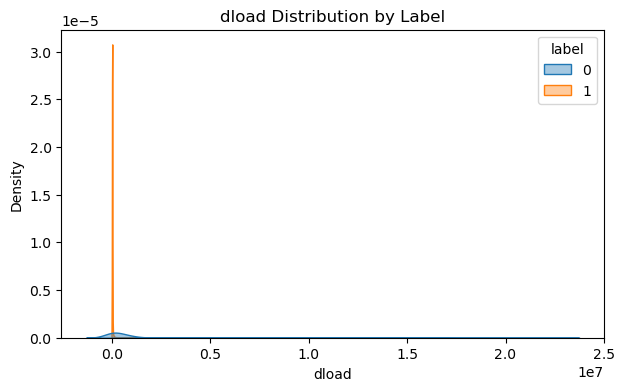

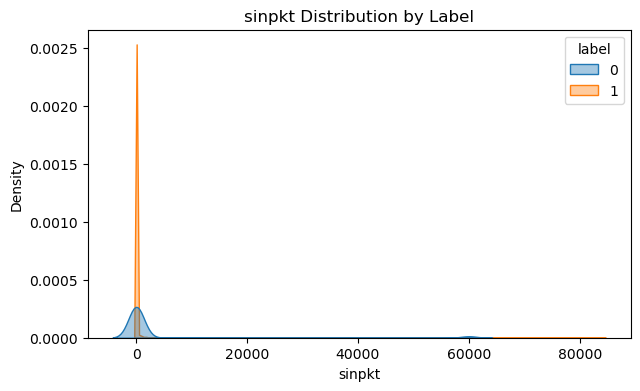

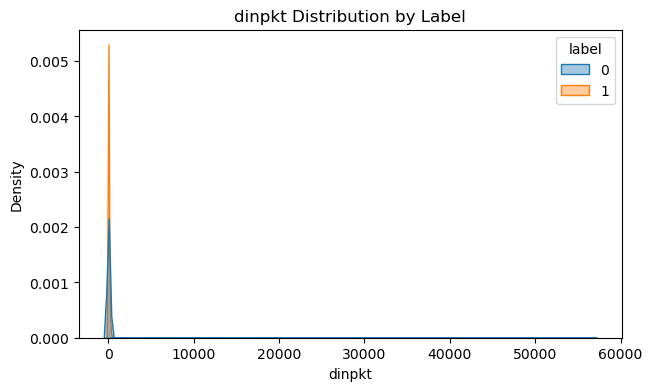

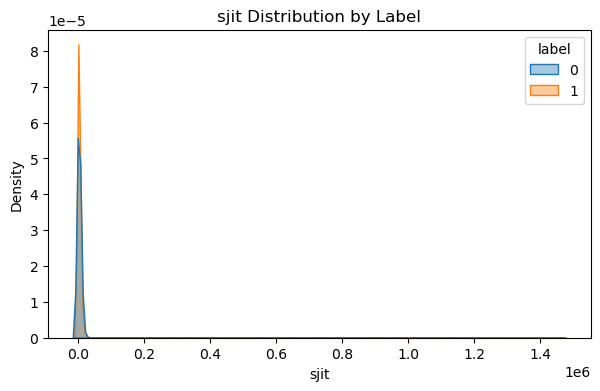

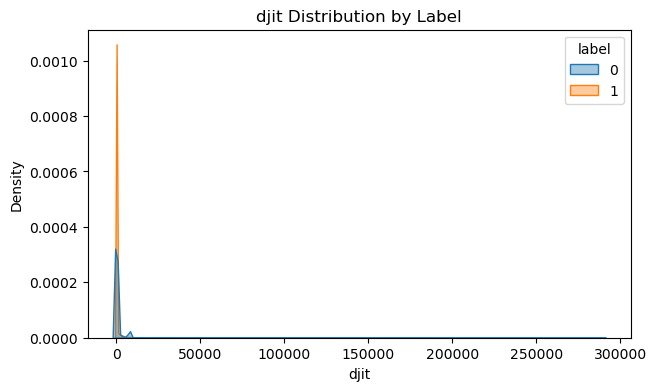

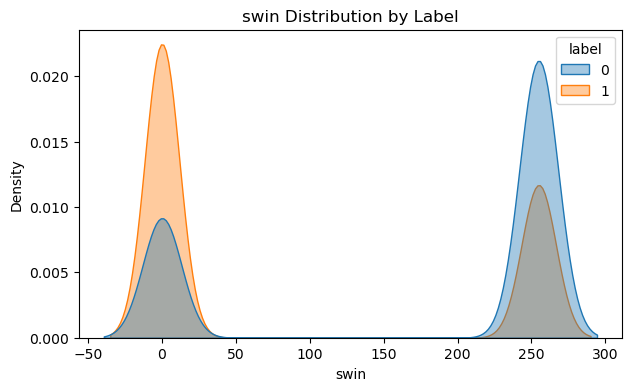

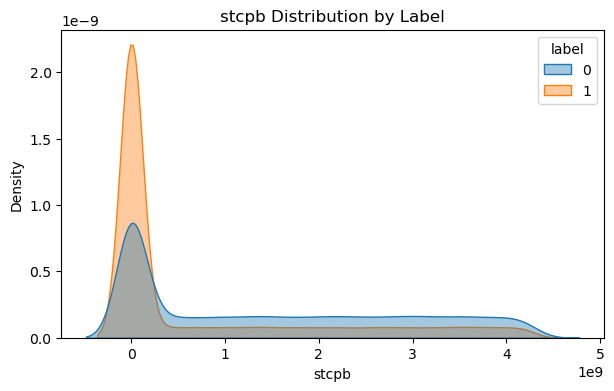

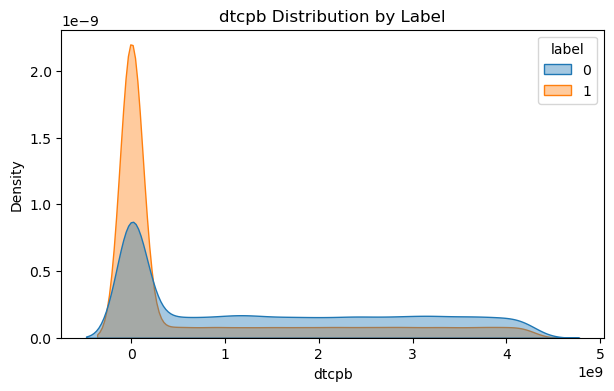

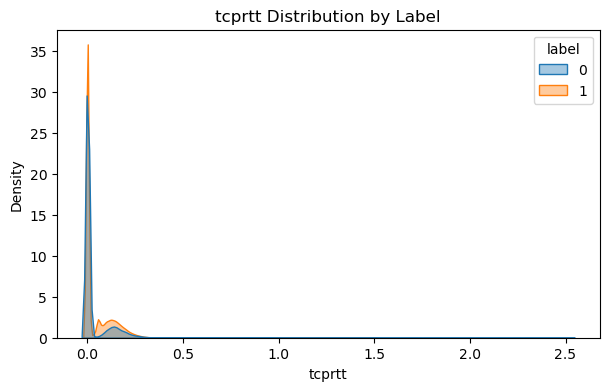

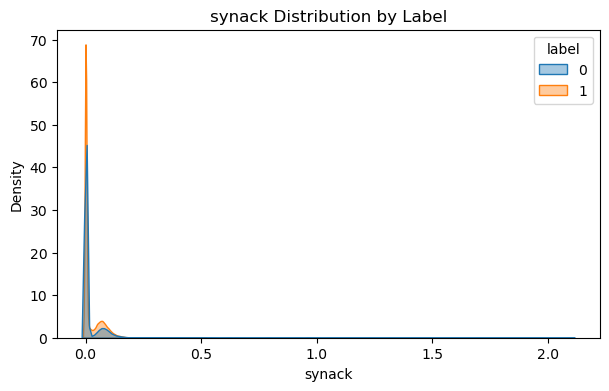

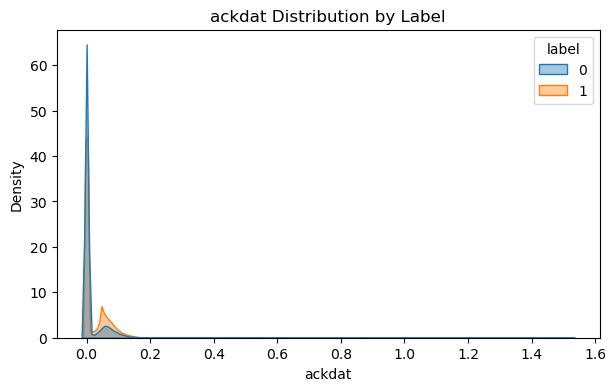

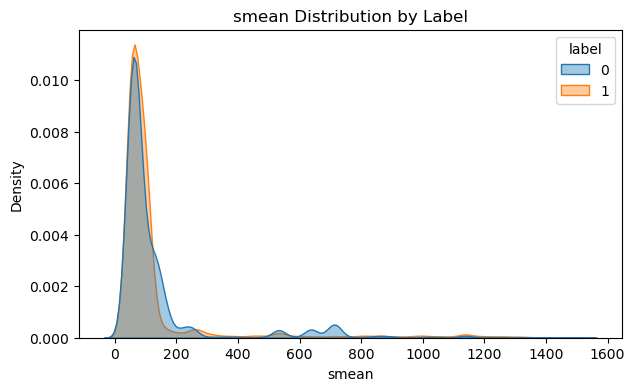

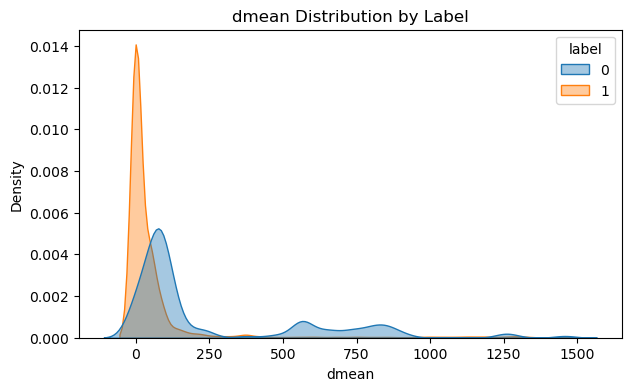

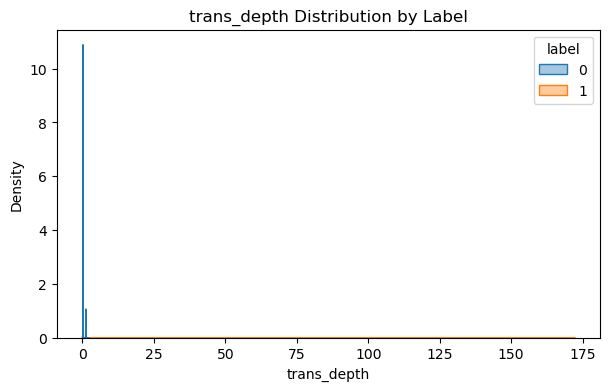

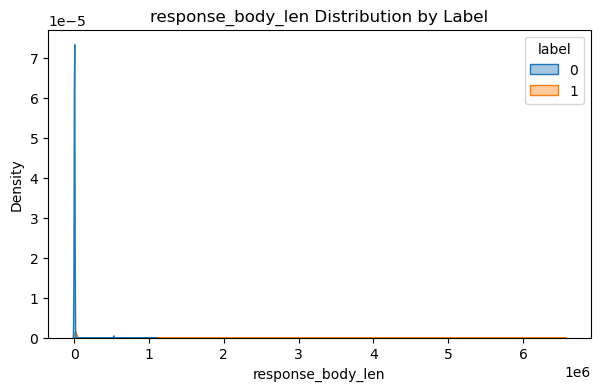

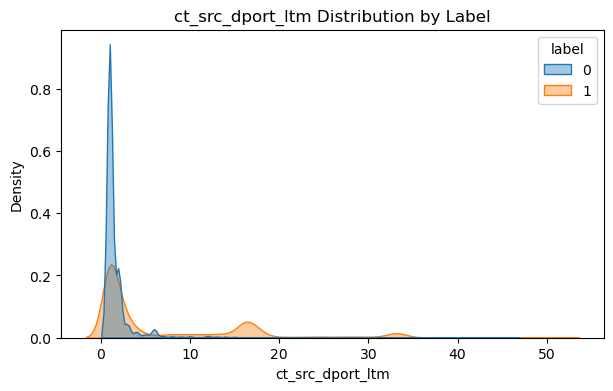

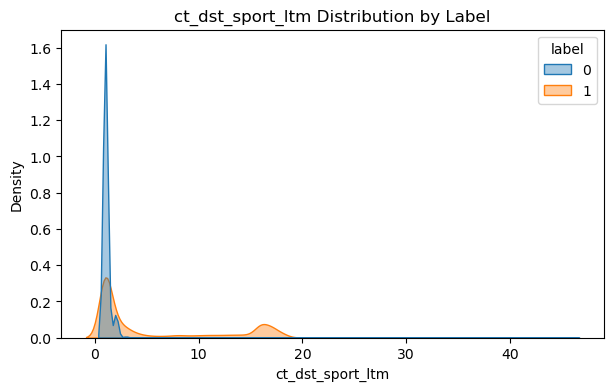

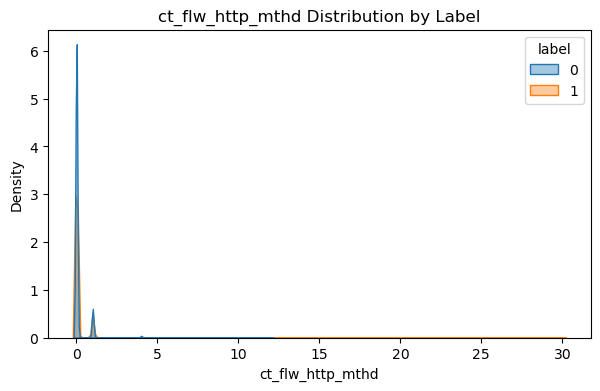

/tmp/ipykernel_7182/492059580.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


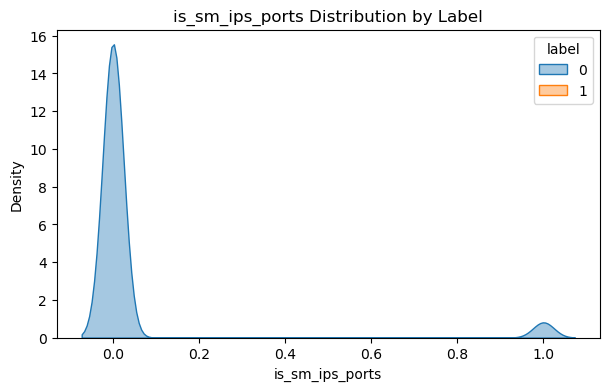

In [47]:
numerical_cols = df_train.drop('label', axis=1).columns

for col in numerical_cols:
    plt.figure(figsize=(7,4))

    sns.kdeplot(
        data=df_train,
        x=col,
        hue='label',
        fill=True,
        common_norm=False,
        alpha=0.4
    )

    plt.title(f"{col} Distribution by Label")
    plt.show()

In [48]:
pd.crosstab(df_train['trans_depth'],df_train['label'])

label,0,1
trans_depth,,
0,50820,106681
1,5111,12636
2,69,11
3,0,2
4,0,3
5,0,2
39,0,2
80,0,1
155,0,1


In [49]:
!pip install xgboost

In [50]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [51]:
X = df_train.drop('label', axis=1)
y = df_train['label']

In [52]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [53]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [54]:
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [55]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

dt = DecisionTreeClassifier(
    random_state=42
)

rf = RandomForestClassifier(
    random_state=42
)

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [56]:
lr_scores = cross_validate(
    lr,
    X_scaled,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [57]:
dt_scores = cross_validate(
    dt,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [58]:
rf_scores = cross_validate(
    rf,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [59]:
xgb_scores = cross_validate(
    xgb,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [60]:
results = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy':[
        lr_scores['test_accuracy'].mean(),
        dt_scores['test_accuracy'].mean(),
        rf_scores['test_accuracy'].mean(),
        xgb_scores['test_accuracy'].mean()
    ],

    'Precision':[
        lr_scores['test_precision'].mean(),
        dt_scores['test_precision'].mean(),
        rf_scores['test_precision'].mean(),
        xgb_scores['test_precision'].mean()
    ],

    'Recall':[
        lr_scores['test_recall'].mean(),
        dt_scores['test_recall'].mean(),
        rf_scores['test_recall'].mean(),
        xgb_scores['test_recall'].mean()
    ],

    'F1 Score':[
        lr_scores['test_f1'].mean(),
        dt_scores['test_f1'].mean(),
        rf_scores['test_f1'].mean(),
        xgb_scores['test_f1'].mean()
    ],

    'ROC-AUC':[
        lr_scores['test_roc_auc'].mean(),
        dt_scores['test_roc_auc'].mean(),
        rf_scores['test_roc_auc'].mean(),
        xgb_scores['test_roc_auc'].mean()
    ]
})

results = results.sort_values(
    by='F1 Score',
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.950508,0.952665,0.975767,0.964077,0.990421
1,XGBoost,0.949801,0.951989,0.975440,0.963570,0.991380
2,Decision Tree,0.940755,0.955570,0.957475,0.956521,0.938583
3,Logistic Regression,0.895991,0.894205,0.960868,0.926338,0.940262


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


X = df_train.drop('label', axis=1)
y = df_train['label']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)


train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)


train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Training Accuracy : {train_acc:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")
print(f"Difference        : {train_acc - test_acc:.4f}")

Training Accuracy : 0.9931
Testing Accuracy  : 0.9499
Difference        : 0.0433


In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [63]:
train_precision = precision_score(y_train, train_pred)
train_recall = recall_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)

test_precision = precision_score(y_test, test_pred)
test_recall = recall_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)

In [64]:
print("="*50)
print("Training Metrics")
print("="*50)
print(f"Accuracy : {train_acc:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1 Score : {train_f1:.4f}")

print("\n" + "="*50)
print("Testing Metrics")
print("="*50)
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Training Metrics
Accuracy : 0.9931
Precision: 0.9925
Recall   : 0.9975
F1 Score : 0.9950

Testing Metrics
Accuracy : 0.9499
Precision: 0.9524
Recall   : 0.9751
F1 Score : 0.9636


In [65]:
print("\n" + "="*50)
print("Train - Test Difference")
print("="*50)
print(f"Accuracy Gap : {train_acc - test_acc:.4f}")
print(f"Precision Gap: {train_precision - test_precision:.4f}")
print(f"Recall Gap   : {train_recall - test_recall:.4f}")
print(f"F1 Score Gap : {train_f1 - test_f1:.4f}")


Train - Test Difference
Accuracy Gap : 0.0433
Precision Gap: 0.0401
Recall Gap   : 0.0223
F1 Score Gap : 0.0314


In [66]:
from sklearn.model_selection import RandomizedSearchCV

In [67]:
param_dict={"n_estimators":[600,700],"max_depth":[20,25],"min_samples_split":[2,5],"min_samples_leaf":[2,4],"bootstrap":[True],"criterion":["gini","entropy"],"max_features":["sqrt"]}

In [68]:
random_search=RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),param_distributions=param_dict,n_iter=30,cv=cv,scoring='f1',random_state=42,n_jobs=-1,verbose=2)

In [69]:
random_search.fit(X,y)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV] END bootstrap=True, criterion=gini, max_depth=25, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=700; total time= 8.0min


/home/jaiveer-minhas/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END bootstrap=True, criterion=entropy, max_depth=25, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=600; total time= 8.0min
[CV] END bootstrap=True, criterion=gini, max_depth=25, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=700; total time= 8.1min
[CV] END bootstrap=True, criterion=gini, max_depth=25, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=700; total time= 8.1min
[CV] END bootstrap=True, criterion=entropy, max_depth=25, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=600; total time= 8.2min
[CV] END bootstrap=True, criterion=entropy, max_depth=25, max_features=sqrt, min_samples_leaf=4, min_samples_split=2, n_estimators=700; total time= 9.2min
[CV] END bootstrap=True, criterion=gini, max_depth=25, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=600; total time= 7.0min
[CV] END bootstrap=True, criterion=entropy, max_depth=25, max_features=sqrt, mi

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True], 'criterion': ['gini', 'entropy'], 'max_depth': [20, 25], 'max_features': ['sqrt'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``

In [70]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 25, 'criterion': 'entropy', 'bootstrap': True}


In [71]:
print("\nBest Cross-Validation F1 Score:")
print(random_search.best_score_)


Best Cross-Validation F1 Score:
0.9651408537505366


In [72]:
rf = RandomForestClassifier(random_state=42,n_estimators= 700, min_samples_split= 5, min_samples_leaf= 2, max_features= 'sqrt', max_depth= 25, criterion= 'entropy', bootstrap= True)
rf.fit(X_train, y_train)

train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)


train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"Training Accuracy : {train_acc:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")
print(f"Difference        : {train_acc - test_acc:.4f}")

Training Accuracy : 0.9851
Testing Accuracy  : 0.9517
Difference        : 0.0333


In [73]:
train_precision = precision_score(y_train, train_pred)
train_recall = recall_score(y_train, train_pred)
train_f1 = f1_score(y_train, train_pred)

test_precision = precision_score(y_test, test_pred)
test_recall = recall_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)

In [74]:
print("="*50)
print("Training Metrics")
print("="*50)
print(f"Accuracy : {train_acc:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall   : {train_recall:.4f}")
print(f"F1 Score : {train_f1:.4f}")

print("\n" + "="*50)
print("Testing Metrics")
print("="*50)
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

print("\n" + "="*50)
print("Train - Test Difference")
print("="*50)
print(f"Accuracy Gap : {train_acc - test_acc:.4f}")
print(f"Precision Gap: {train_precision - test_precision:.4f}")
print(f"Recall Gap   : {train_recall - test_recall:.4f}")
print(f"F1 Score Gap : {train_f1 - test_f1:.4f}")

Training Metrics
Accuracy : 0.9851
Precision: 0.9826
Recall   : 0.9957
F1 Score : 0.9891

Testing Metrics
Accuracy : 0.9517
Precision: 0.9510
Recall   : 0.9796
F1 Score : 0.9651

Train - Test Difference
Accuracy Gap : 0.0333
Precision Gap: 0.0316
Recall Gap   : 0.0161
F1 Score Gap : 0.0240


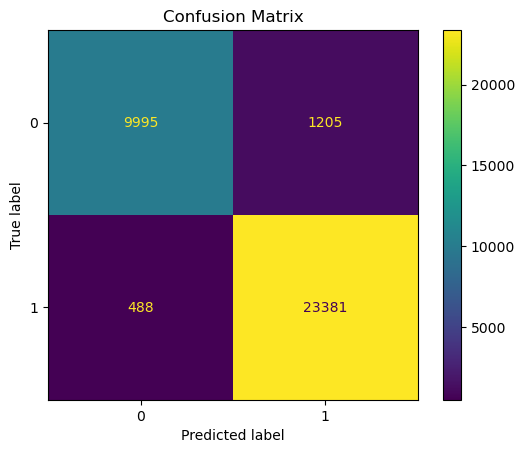

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Confusion Matrix")
plt.show()

In [76]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

           0       0.95      0.89      0.92     11200
           1       0.95      0.98      0.97     23869

    accuracy                           0.95     35069
   macro avg       0.95      0.94      0.94     35069
weighted avg       0.95      0.95      0.95     35069



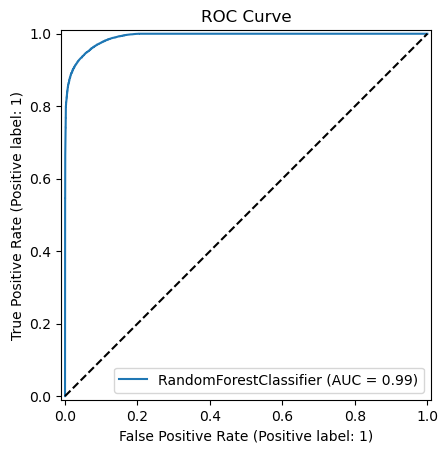

In [77]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(rf, X_test, y_test)

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.show()

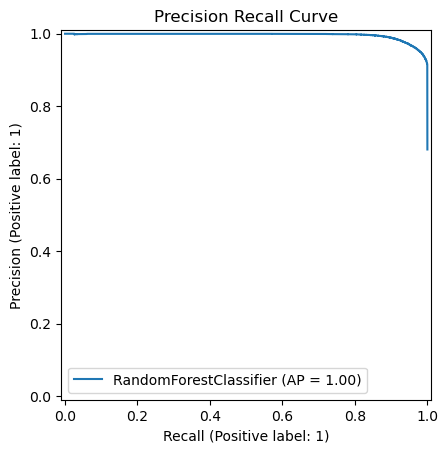

In [78]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(rf, X_test, y_test)

plt.title("Precision Recall Curve")
plt.show()

In [80]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

              Feature  Importance
8               dload    0.112168
7               sload    0.093895
6                rate    0.087313
16             tcprtt    0.075166
18             ackdat    0.072139
19              smean    0.064995
17             synack    0.062529
20              dmean    0.055534
10             dinpkt    0.043293
0                 dur    0.041240
5               dpkts    0.038413
9              sinpkt    0.037451
11               sjit    0.027088
24   ct_dst_sport_ltm    0.025771
3               state    0.021876
23   ct_src_dport_ltm    0.019732
12               djit    0.019611
1               proto    0.018854
2             service    0.018055
4               spkts    0.017087
13               swin    0.011190
26    is_sm_ips_ports    0.009579
15              dtcpb    0.008400
14              stcpb    0.008215
22  response_body_len    0.004934
25   ct_flw_http_mthd    0.002747
21        trans_depth    0.002724


In [81]:
!pip install shap 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 777.0 kB/s eta 0:00:00m eta 0:00:010:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]━━━━━━━━━━━━━ 2/3 [shap]


In [84]:
import numpy
print(numpy.__version__)

2.4.3


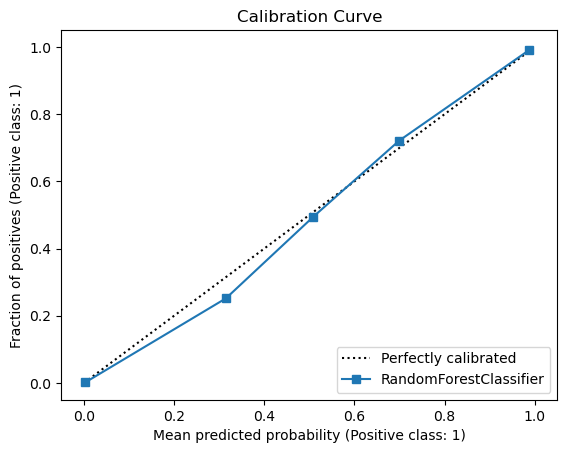

In [87]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("Calibration Curve")
plt.show()